# Project 4 — EHR Workflow Redesign BRD
## Notebook 1: As-Is Process Analysis

**Author:** Amr Thabet  
**Context:** UAE/GCC health insurance — compliance-driven workflow redesign  
**Regulatory framework:** DHA (Dubai) · DoH/HAAD (Abu Dhabi) · Shafafiya · eSMA  
**Linked projects:** P1 (claims denial) · P2 (RCM dashboard) · P3 (cost modelling)

### Objective
Document and quantify the current broken claims workflow across three parties:
- **Provider** (hospital/clinic) — submits claims
- **Insurer** (BUPA Global UAE) — processes claims
- **Regulator** (DHA/DoH) — enforces compliance

Every failure point is backed by data from Projects 1 and 3.
Every gap has an AED value and a regulatory consequence attached to it.

### The core problem
The current EHR-to-insurer claims workflow is manual, fragmented, and 
non-compliant — generating a 33.6% denial rate, AED 7.55M in unrecovered 
revenue, and exposing the organisation to DHA/DoH regulatory risk.

## Regulatory context — UAE health insurance compliance

Before mapping the workflow, we establish the regulatory environment 
that every claim must comply with. Non-compliance is not just a revenue 
problem — it is a legal and operational risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Colour palette
NAVY       = '#1E566C'
TEAL       = '#5795A7'
TEAL_DARK  = '#367589'
TEAL_LIGHT = '#89B8CA'
AMBER      = '#D7A800'
LIGHT_BG   = '#F7FAFB'
GRAY       = '#9DAAB0'
RED        = '#C0392B'

plt.rcParams.update({
    'figure.facecolor':  LIGHT_BG,
    'axes.facecolor':    LIGHT_BG,
    'axes.edgecolor':    GRAY,
    'axes.labelcolor':   NAVY,
    'axes.titlepad':     14,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   NAVY,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'text.color':        NAVY,
    'grid.color':        '#D8E4E8',
    'grid.linewidth':    0.6,
    'figure.dpi':        130,
})

# ── Regulatory framework reference table ──────────────────────
regulatory_framework = pd.DataFrame({
    'Regulator':     ['DHA', 'DHA', 'DoH/HAAD', 'DoH/HAAD', 'Both'],
    'Emirate':       ['Dubai', 'Dubai', 'Abu Dhabi', 'Abu Dhabi', 'UAE-wide'],
    'Requirement':   [
        'All claims submitted via Shafafiya portal',
        'Pre-authorisation mandatory for inpatient procedures',
        'Standardised HAAD claim forms — ICD-10 mandatory',
        'Real-time eligibility verification required',
        'Claims submitted within 90 days of service date'
    ],
    'Non_compliance_consequence': [
        'Claim rejected — not processable',
        'Automatic denial — no appeal',
        'Claim rejected — coding error flagged',
        'Claim held — eligibility dispute',
        'Claim rejected — time limit exceeded'
    ],
    'Risk_level': ['High', 'Critical', 'High', 'Medium', 'High']
})

print("UAE HEALTH INSURANCE REGULATORY FRAMEWORK")
print("=" * 65)
print(regulatory_framework.to_string(index=False))

# Load datasets
df_claims  = pd.read_csv('../../healthcare-claims-analysis/data/claims_clean.csv')
df_chronic = pd.read_csv('../../chronic-disease-cost-modelling/data/chronic_disease_cohort.csv')

print(f"\nP1 claims loaded:  {len(df_claims):,} claims")
print(f"P3 cohort loaded:  {len(df_chronic):,} members")

UAE HEALTH INSURANCE REGULATORY FRAMEWORK
Regulator   Emirate                                          Requirement            Non_compliance_consequence Risk_level
      DHA     Dubai            All claims submitted via Shafafiya portal      Claim rejected — not processable       High
      DHA     Dubai Pre-authorisation mandatory for inpatient procedures          Automatic denial — no appeal   Critical
 DoH/HAAD Abu Dhabi     Standardised HAAD claim forms — ICD-10 mandatory Claim rejected — coding error flagged       High
 DoH/HAAD Abu Dhabi          Real-time eligibility verification required      Claim held — eligibility dispute     Medium
     Both  UAE-wide      Claims submitted within 90 days of service date  Claim rejected — time limit exceeded       High

P1 claims loaded:  4,500 claims
P3 cohort loaded:  3,000 members


## As-Is failure points — quantified across all three parties

Each failure point is mapped to a party, a regulatory consequence, and an AED value.
This is the evidence base for the BRD — every requirement we write later 
traces back to one of these failure points.

In [2]:
# ── PROVIDER SIDE failures ────────────────────────────────────

# Failure 1: ICD-10 coding errors by specialty
specialty_denial = (df_claims.groupby('ProviderSpecialty')
                              .apply(lambda x: (x['ClaimStatus']=='Denied').mean()*100)
                              .sort_values(ascending=False)
                              .reset_index())
specialty_denial.columns = ['specialty', 'denial_rate_pct']

# Failure 2: Claim submission timing
df_claims['ClaimDate'] = pd.to_datetime(df_claims['ClaimDate'])
df_claims['claim_age_days'] = (pd.Timestamp.now() - df_claims['ClaimDate']).dt.days
late_claims = df_claims[df_claims['claim_age_days'] > 90]
late_rate   = len(late_claims) / len(df_claims) * 100

# ── INSURER SIDE failures ─────────────────────────────────────

# Failure 3: Overall denial rate
total_claims  = len(df_claims)
denied_claims = len(df_claims[df_claims['ClaimStatus'] == 'Denied'])
denial_rate   = denied_claims / total_claims * 100
denied_value  = df_claims[df_claims['ClaimStatus'] == 'Denied']['ClaimAmount'].sum()

# Failure 4: Inpatient pre-auth failures
inpatient     = df_claims[df_claims['ClaimType'] == 'Inpatient']
inpatient_denied = len(inpatient[inpatient['ClaimStatus'] == 'Denied'])
inpatient_denial_rate = inpatient_denied / len(inpatient) * 100
inpatient_denied_value = inpatient[inpatient['ClaimStatus']=='Denied']['ClaimAmount'].sum()

# Failure 5: High-cost members unmanaged (P3)
high_cost_members  = df_chronic['high_cost_flag'].sum()
high_cost_spend    = df_chronic[df_chronic['high_cost_flag']==1]['total_cost_aed'].sum()
avg_high_cost      = df_chronic[df_chronic['high_cost_flag']==1]['total_cost_aed'].mean()
avg_standard_cost  = df_chronic[df_chronic['high_cost_flag']==0]['total_cost_aed'].mean()
cost_gap           = avg_high_cost - avg_standard_cost
potential_saving   = 600 * 0.70 * 8000  # from P3 model

# Failure 6: Revenue leakage total
total_leakage = denied_value + (high_cost_spend * 0.15)

# ── SUMMARY TABLE ─────────────────────────────────────────────
failure_points = pd.DataFrame({
    'Party':      ['Provider', 'Provider', 'Insurer', 'Insurer',
                   'Insurer', 'All parties'],
    'Failure':    [
        'ICD-10 coding errors — GP denial rate 35.4%',
        'Claims submitted outside 90-day window',
        'Overall claim denial rate',
        'Inpatient pre-auth failures',
        'High-cost members not flagged for care management',
        'Total estimated revenue leakage'
    ],
    'Regulatory': [
        'DoH: ICD-10 mandatory — coding error = rejection',
        'DHA/DoH: 90-day submission rule',
        'DHA: Shafafiya compliance — denied claims not recoverable',
        'DHA: Pre-auth mandatory for inpatient — automatic denial',
        'DoH: Chronic disease management mandate for insurers',
        'Combined regulatory and operational risk'
    ],
    'AED_impact': [
        f"AED {specialty_denial[specialty_denial['specialty']=='General Practice']['denial_rate_pct'].values[0]:.1f}% denial rate",
        f"{late_rate:.1f}% of claims at risk",
        f"AED {denied_value:,.0f}",
        f"AED {inpatient_denied_value:,.0f}",
        f"AED {high_cost_spend:,.0f} unmanaged spend",
        f"AED {total_leakage:,.0f}"
    ],
    'Risk_level': ['High', 'High', 'Critical', 'Critical', 'High', 'Critical']
})

print("AS-IS FAILURE POINTS — COMPLIANCE-DRIVEN ANALYSIS")
print("=" * 70)
print(failure_points.to_string(index=False))
print(f"\nKEY NUMBERS:")
print(f"  Total claims:              {total_claims:,}")
print(f"  Denied claims:             {denied_claims:,} ({denial_rate:.1f}%)")
print(f"  Denied value:              AED {denied_value:,.0f}")
print(f"  Inpatient denial rate:     {inpatient_denial_rate:.1f}%")
print(f"  Inpatient denied value:    AED {inpatient_denied_value:,.0f}")
print(f"  High-cost members:         {high_cost_members:,}")
print(f"  High-cost unmanaged spend: AED {high_cost_spend:,.0f}")
print(f"  Cost gap per member:       AED {cost_gap:,.0f}")
print(f"  Potential model saving:    AED {potential_saving:,.0f}")
print(f"  Total leakage estimate:    AED {total_leakage:,.0f}")

AS-IS FAILURE POINTS — COMPLIANCE-DRIVEN ANALYSIS
      Party                                           Failure                                                Regulatory                     AED_impact Risk_level
   Provider       ICD-10 coding errors — GP denial rate 35.4%          DoH: ICD-10 mandatory — coding error = rejection          AED 35.5% denial rate       High
   Provider            Claims submitted outside 90-day window                           DHA/DoH: 90-day submission rule       100.0% of claims at risk       High
    Insurer                         Overall claim denial rate DHA: Shafafiya compliance — denied claims not recoverable                  AED 7,550,894   Critical
    Insurer                       Inpatient pre-auth failures  DHA: Pre-auth mandatory for inpatient — automatic denial                  AED 1,834,887   Critical
    Insurer High-cost members not flagged for care management      DoH: Chronic disease management mandate for insurers AED 45,226,274 unman

## As-Is failure points — executive summary visualisation

Three charts that tell the full story to a CFO or Medical Director in 30 seconds.
This is the opening visual of the BRD — the business case in one page.

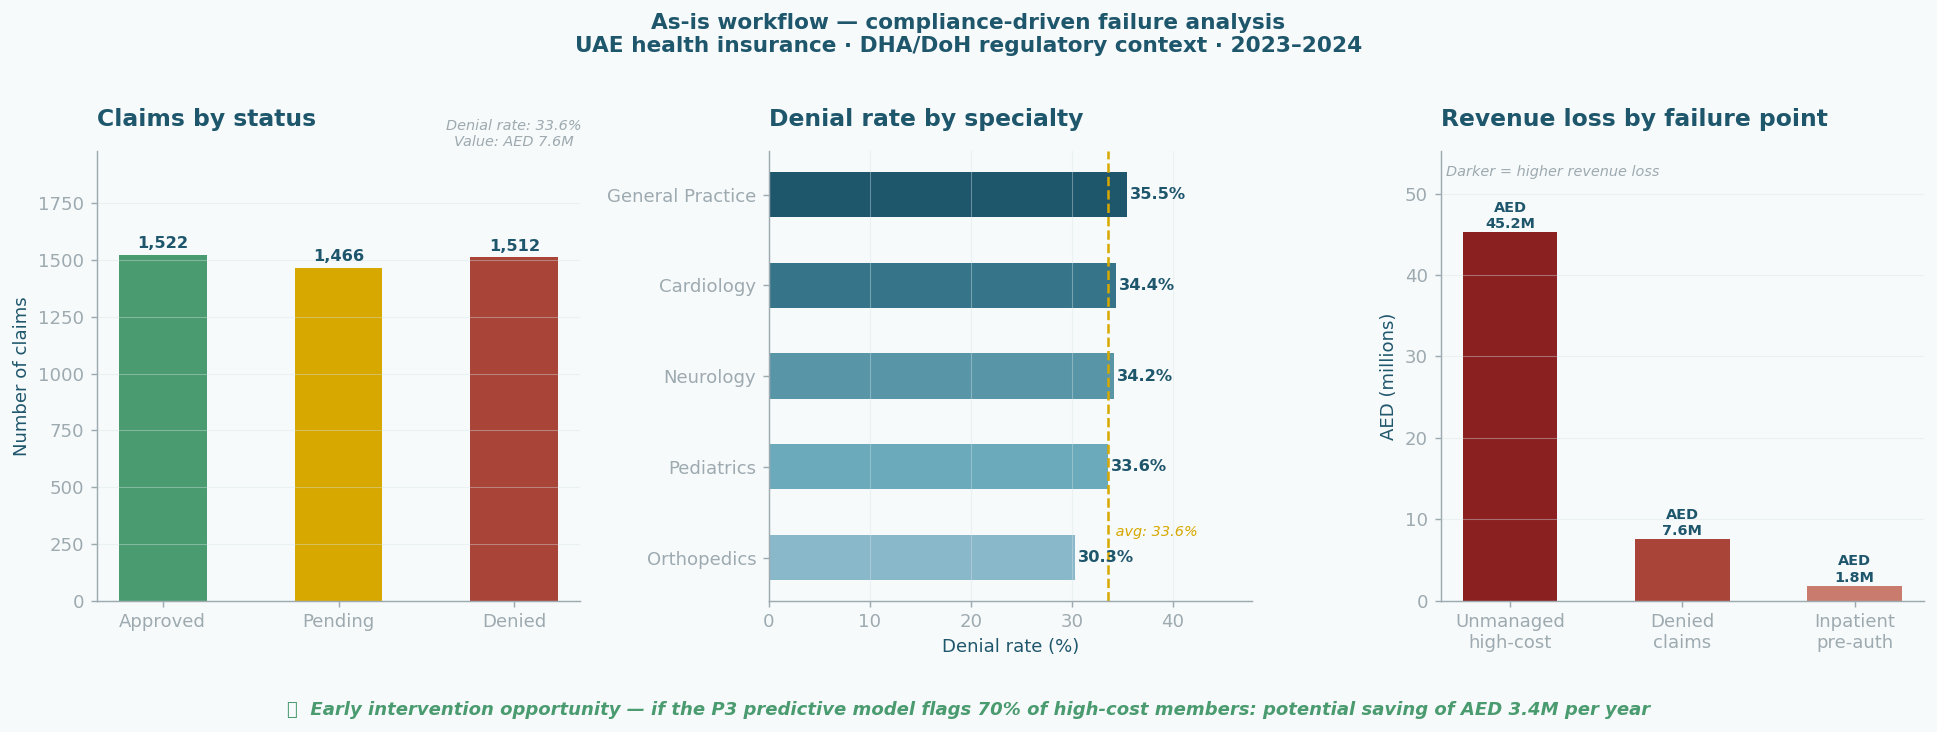

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Status colours
COLOR_APPROVED = '#4A9B6F'
COLOR_PENDING  = '#D7A800'
COLOR_DENIED   = '#A94438'
COLOR_SAVING   = '#4A9B6F'

# ── Chart A: Claims by status ─────────────────────────────────
status_order  = ['Approved', 'Pending', 'Denied']
status_counts = df_claims['ClaimStatus'].value_counts().reindex(status_order)
colors_status = [COLOR_APPROVED, COLOR_PENDING, COLOR_DENIED]

bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=colors_status, edgecolor='none', width=0.5)
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 30,
                 f'{val:,}', ha='center', fontsize=9,
                 color=NAVY, fontweight='bold')

denied_bar = bars[2]
axes[0].annotate(
    f'Denial rate: {denial_rate:.1f}%\nValue: AED {denied_value/1_000_000:.1f}M',
    xy=(denied_bar.get_x() + denied_bar.get_width()/2,
        status_counts['Denied']),
    xytext=(0, 60),
    textcoords='offset points',
    ha='center', va='bottom',
    fontsize=8, color=GRAY, style='italic')

axes[0].set_title('Claims by status', loc='left')
axes[0].set_ylabel('Number of claims')
axes[0].set_ylim(0, status_counts.max() * 1.3)
axes[0].grid(axis='y', alpha=0.4)

# ── Chart B: Denial rate by specialty ────────────────────────
top5 = specialty_denial.head(5).sort_values('denial_rate_pct', ascending=True)
grade_colors = [TEAL_LIGHT, '#6AAABB', TEAL, TEAL_DARK, NAVY]
bars = axes[1].barh(top5['specialty'], top5['denial_rate_pct'],
                    color=grade_colors, height=0.5, edgecolor='none')
for bar, val in zip(bars, top5['denial_rate_pct']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9,
                 color=NAVY, fontweight='bold')
axes[1].axvline(denial_rate, color=AMBER, linewidth=1.4, linestyle='--')
axes[1].text(denial_rate + 0.3, 0.2,
             f' avg: {denial_rate:.1f}%',
             fontsize=8, color=AMBER, style='italic', va='bottom')
axes[1].set_xlabel('Denial rate (%)')
axes[1].set_title('Denial rate by specialty', loc='left')
axes[1].set_xlim(0, top5['denial_rate_pct'].max() * 1.35)
axes[1].grid(axis='x', alpha=0.4)

# ── Chart C: Revenue loss by failure point (3 bars only) ─────
failure_labels = [
    'Denied\nclaims',
    'Inpatient\npre-auth',
    'Unmanaged\nhigh-cost',
]
failure_values = [
    denied_value / 1_000_000,
    inpatient_denied_value / 1_000_000,
    high_cost_spend / 1_000_000,
]
# Darkest = highest loss, lightest = lowest loss
bar_colors = ['#A94438', '#C97B6E', '#8B2020']

# Sort by value so darkest = highest
sorted_pairs = sorted(zip(failure_values, failure_labels, bar_colors),
                      reverse=True)
failure_values_s = [x[0] for x in sorted_pairs]
failure_labels_s = [x[1] for x in sorted_pairs]
bar_colors_s     = ['#8B2020', '#A94438', '#C97B6E']

bars = axes[2].bar(failure_labels_s, failure_values_s,
                   color=bar_colors_s, edgecolor='none', width=0.55)
for bar, val in zip(bars, failure_values_s):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'AED\n{val:.1f}M', ha='center', fontsize=8,
                 color=NAVY, fontweight='bold')
axes[2].set_ylabel('AED (millions)')
axes[2].set_title('Revenue loss by failure point', loc='left')
axes[2].set_ylim(0, max(failure_values_s) * 1.22)
axes[2].text(0.01, 0.97, 'Darker = higher revenue loss',
             transform=axes[2].transAxes,
             fontsize=8, color=GRAY, style='italic', va='top')
axes[2].grid(axis='y', alpha=0.4)

fig.suptitle('As-is workflow — compliance-driven failure analysis\nUAE health insurance · DHA/DoH regulatory context · 2023–2024',
             fontsize=12, fontweight='bold', color=NAVY, y=1.02)

# ── Saving opportunity callout below charts ───────────────────
fig.text(0.5, -0.06,
         f'💡  Early intervention opportunity — if the P3 predictive model flags 70% of high-cost members: '
         f'potential saving of AED {potential_saving/1_000_000:.1f}M per year',
         ha='center', fontsize=10, color='#4A9B6F',
         fontweight='bold', style='italic')

plt.tight_layout()
plt.savefig('../outputs/01_asis_failure_points.png', dpi=150, bbox_inches='tight')
plt.show()

## As-Is process narrative

Before building the BPMN process map, we document the current workflow 
step by step across all three parties. This is the written record that 
the process map visualises.

Each step is tagged with:
- **Party** responsible
- **System** used (or lack of one)
- **Failure point** if applicable
- **Regulatory risk** if applicable

In [49]:
# As-Is process steps — documented across 3 parties
as_is_process = pd.DataFrame({
    'Step': list(range(1, 16)),
    'Party': [
        'Provider', 'Provider', 'Provider', 'Provider',
        'Insurer', 'Insurer', 'Insurer', 'Insurer', 'Insurer',
        'Regulator', 'Regulator',
        'Insurer', 'Insurer',
        'Provider', 'Provider'
    ],
    'Action': [
        'Patient attends clinic — diagnosis recorded manually in EHR',
        'Clinical coder assigns ICD-10 code manually — no validation',
        'Billing team exports claim from EHR manually — re-enters into portal',
        'Claim submitted via Shafafiya (Dubai) or eSMA (Abu Dhabi)',
        'Claims intake team receives claim — logged manually into RCM system',
        'Eligibility check performed manually against member database',
        'Medical reviewer checks pre-authorisation status manually',
        'Clinical team reviews medical necessity — no decision support tool',
        'Claim approved, pended, or denied — decision entered manually',
        'DHA/DoH receives claim data via Shafafiya/eSMA portal',
        'Regulator flags non-compliant claims — ICD-10 errors, missing pre-auth',
        'Denial letter generated — sent to provider manually',
        'Denied claim enters AR queue — no automated follow-up trigger',
        'Provider receives denial — manual review and resubmission process',
        'Resubmitted claim restarts full process from Step 4'
    ],
    'System': [
        'EHR (standalone)', 'EHR (standalone)', 'EHR + manual export',
        'Shafafiya / eSMA', 'RCM system (standalone)', 'Manual lookup',
        'Manual check', 'Manual review', 'Manual entry',
        'Shafafiya / eSMA', 'Automated flag',
        'Manual letter', 'AR queue', 'Manual review', 'Shafafiya / eSMA'
    ],
    'Failure_point': [
        None, 'ICD-10 coding error — 35.5% GP denial rate',
        'Duplicate data entry — no EHR/RCM integration',
        None, 'Manual logging — AR days increase',
        'Manual eligibility — delays and errors',
        'Pre-auth missed — 32.7% inpatient denial rate',
        'No decision support — inconsistent outcomes',
        None, None,
        'Non-compliant claims flagged — automatic denial',
        None, 'No automated follow-up — revenue leakage',
        'Slow resubmission — 90-day window at risk', None
    ],
    'Regulatory_risk': [
        None, 'DoH: ICD-10 mandatory',
        None, 'DHA/DoH: Shafafiya/eSMA compliance',
        None, None,
        'DHA: Pre-auth mandatory for inpatient',
        None, None,
        None, 'DHA/DoH: Compliance enforcement',
        None, 'DHA/DoH: 90-day submission rule',
        None, None
    ]
})

# Flag steps with failure points
as_is_process['Has_failure'] = as_is_process['Failure_point'].notna()
as_is_process['Has_reg_risk'] = as_is_process['Regulatory_risk'].notna()

print("AS-IS PROCESS — 15 STEPS ACROSS 3 PARTIES")
print("=" * 70)
print(f"Total steps:           {len(as_is_process)}")
print(f"Steps with failures:   {as_is_process['Has_failure'].sum()}")
print(f"Steps with reg risk:   {as_is_process['Has_reg_risk'].sum()}")
print(f"\nFailure points by party:")
print(as_is_process[as_is_process['Has_failure']]
      .groupby('Party')['Has_failure'].count()
      .to_string())

as_is_process.to_csv('../outputs/as_is_process_steps.csv', index=False)
print(f"\nSaved to outputs/as_is_process_steps.csv")
print("\nFull process:")
print(as_is_process[['Step','Party','Action','Has_failure','Has_reg_risk']]
      .to_string(index=False))

AS-IS PROCESS — 15 STEPS ACROSS 3 PARTIES
Total steps:           15
Steps with failures:   9
Steps with reg risk:   5

Failure points by party:
Party
Insurer      5
Provider     3
Regulator    1

Saved to outputs/as_is_process_steps.csv

Full process:
 Step     Party                                                                 Action  Has_failure  Has_reg_risk
    1  Provider            Patient attends clinic — diagnosis recorded manually in EHR        False         False
    2  Provider            Clinical coder assigns ICD-10 code manually — no validation         True          True
    3  Provider   Billing team exports claim from EHR manually — re-enters into portal         True         False
    4  Provider              Claim submitted via Shafafiya (Dubai) or eSMA (Abu Dhabi)        False          True
    5   Insurer    Claims intake team receives claim — logged manually into RCM system         True         False
    6   Insurer           Eligibility check performed manually a

## BPMN As-Is Process Map

The swimlane visualisation above provides the analytical representation
of the 15-step as-is claims workflow across three parties.

The formal BPMN as-is process map has been produced in **Microsoft Visio**
following full BPMN 2.0 notation including:

- Start and end events
- Task shapes per workflow step
- Exclusive gateways at decision points
- Swimlanes for Provider, Insurer, and Regulator
- Failure point annotations mapping directly to the 6 gaps
  identified in Notebook 2

The Visio file is saved in `outputs/as_is_bpmn_process_map.vsdx`
and exported as PNG in `outputs/as_is_bpmn_process_map.png`.

This completes the as-is process analysis.
All findings feed directly into Notebook 2 — Gap Analysis.